### 42028 : Deep Learning and CNN
### Assignment 1

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To develop SVM and Neural Network classifiers for handwritten mathematical symbol classification.
- To use Histogram Of Oriented Gradients (HoG), Local Binary Pattern (LBP), Raw images/pixels, and any other feature for classification

### Contents
1. Section 1 : SVM with Raw Pixels
2. Section 2 : SVM with HoG
3. Section 3 : SVM with LBP

### File Outcome
*Using Support Vector Machine algorithm with Raw Pixels, HoG, and LBP features.*

### Libraries

In [19]:
#Importing required libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn import svm
from sklearn import metrics

### Section 1 : SVM with Raw Pixels

In [11]:
#Importing data
raw_pixel_x_train = np.load('./train/raw_pixel_train_images.npy')
raw_pixel_y_train = np.load('./train/raw_pixel_train_labels.npy')
raw_pixel_x_test = np.load('./test/raw_pixel_test_images.npy')
raw_pixel_y_test = np.load('./test/raw_pixel_test_labels.npy')

In [27]:
#Defining SVM model for Raw Pixel
svm_model_raw_pixel = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)

In [21]:
#Fitting the SVM model for raw images
svm_model_raw_pixel.fit(raw_pixel_x_train, raw_pixel_y_train)
print("SVM model trained on raw pixel data")

SVM model trained on raw pixel data


In [22]:
#Predicting results on raw pixel data
raw_pixel_y_pred = svm_model_raw_pixel.predict(raw_pixel_x_test)

In [23]:
#Evaluating predicted results against testing labels
accuracy = metrics.accuracy_score(raw_pixel_y_test, raw_pixel_y_pred)
print("Accuracy of SVM on raw images : {:.2f}".format(accuracy))

Accuracy of SVM on raw images : 0.91


In [24]:
raw_pixel_cm = metrics.confusion_matrix(raw_pixel_y_test, raw_pixel_y_pred)
print(raw_pixel_cm)

[[126   0   0   2   0   0   1   0   0   8]
 [  0 146   0   0   0   0   1   1   0   3]
 [  0   0 153   1   1   0   1   0   0   0]
 [  0   0   0 150   1   0   0   5   2   1]
 [  2   1   1  11 117   1   0  16   8   1]
 [  0   0   0   0   0 141   0   0   0   0]
 [  3  14   0   0   0   0 125   1   0   0]
 [  0   0   0   4   7   0   0 127   0   2]
 [  1   0   0   0  11   1   0   1 139   0]
 [  4   2   0   9   3   0   3   1   0 140]]


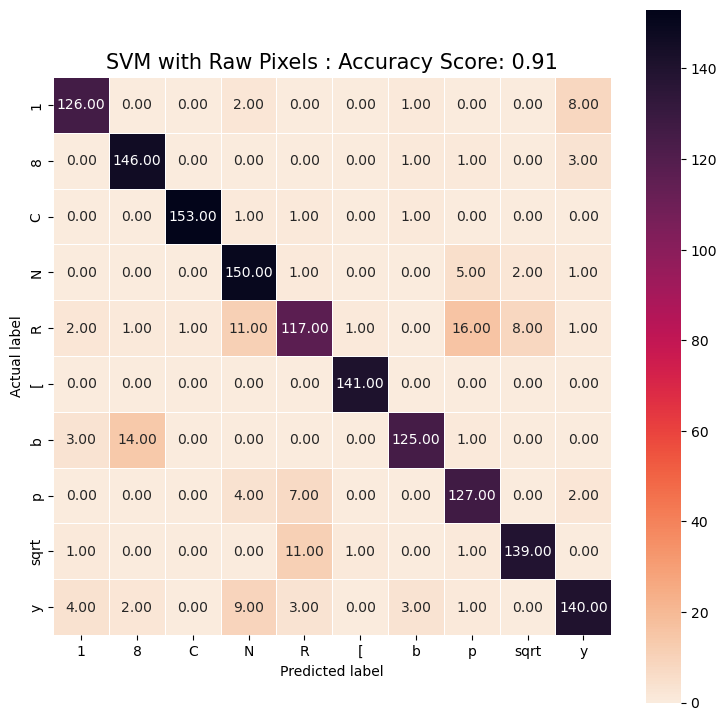

In [25]:
# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
class_names = ['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']
sns.heatmap(raw_pixel_cm, 
            annot=True,
            linewidths=0.5,
            fmt=".2f",
            square = True,
            cmap = 'rocket_r',
            xticklabels = class_names,
            yticklabels = class_names
           );
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'SVM with Raw Pixels : Accuracy Score: {:.2f}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [18]:
report = metrics.classification_report(raw_pixel_y_test, raw_pixel_y_pred)
print("Classification Report for SVM with Raw Pixel:")
print(report)

Classification Report for SVM with Raw Pixel:
              precision    recall  f1-score   support

           1       0.87      0.94      0.91       137
           8       0.93      0.95      0.94       151
           C       0.98      0.99      0.98       156
           N       0.91      0.91      0.91       159
           R       0.84      0.75      0.79       158
           [       0.97      0.99      0.98       141
           b       0.92      0.90      0.91       143
           p       0.88      0.91      0.90       140
        sqrt       0.89      0.92      0.91       153
           y       0.90      0.86      0.88       162

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



### Section 2 : SVM with HoG Features

In [29]:
#Importing data
hog_x_train = np.load('./train/hog_train_images.npy')
hog_y_train = np.load('./train/hog_train_labels.npy')
hog_x_test = np.load('./test/hog_test_images.npy')
hog_y_test = np.load('./test/hog_test_labels.npy')

In [41]:
#Defining SVM model for HoG
svm_model_hog = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)

In [32]:
#Fitting the SVM model for HoG
svm_model_hog.fit(hog_x_train, hog_y_train)
print("SVM model trained on HoG data")

SVM model trained on HoG data


In [33]:
#Predicting results on HoG data
hog_y_pred = svm_model_hog.predict(hog_x_test)

In [34]:
#Evaluating predicted results against testing labels
accuracy = metrics.accuracy_score(hog_y_test, hog_y_pred)
print("Accuracy of SVM on HoG : {:.2f}".format(accuracy))

Accuracy of SVM on HoG : 0.94


In [37]:
hog_cm = metrics.confusion_matrix(hog_y_test, hog_y_pred)
print(hog_cm)

[[131   0   0   0   0   4   0   0   0   2]
 [  0 147   0   0   0   0   1   1   0   2]
 [  0   0 154   0   0   1   1   0   0   0]
 [  1   0   0 153   4   0   1   0   0   0]
 [  0   3   2   4 137   0   0   6   6   0]
 [  3   0   1   0   3 132   0   0   0   2]
 [  2   5   1   0   0   0 134   0   0   1]
 [  2   0   0   0   5   0   0 132   0   1]
 [  0   0   0   0   3   1   0   0 148   1]
 [  3   7   0   0   2   1   6   2   0 141]]


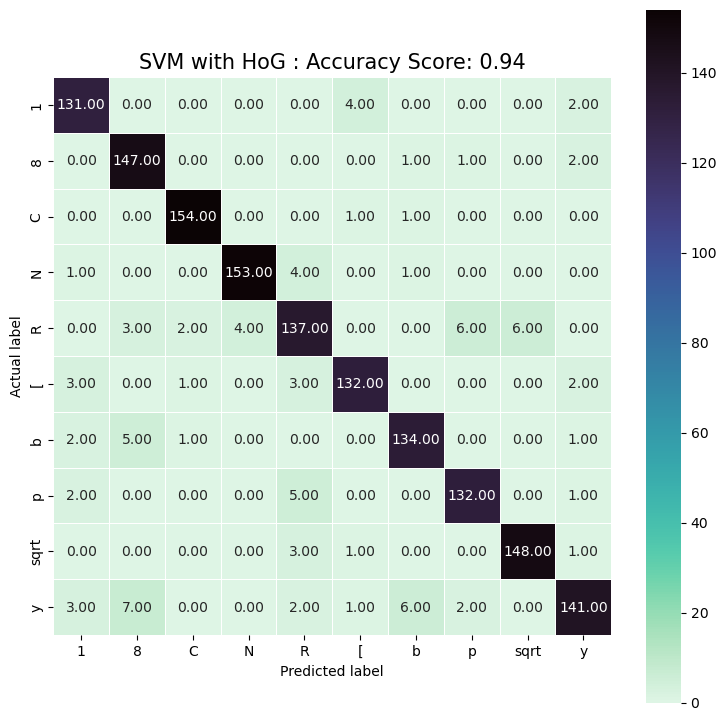

In [38]:
# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
class_names = ['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']
sns.heatmap(hog_cm, 
            annot=True,
            linewidths=0.5,
            fmt=".2f",
            square = True,
            cmap = 'mako_r',
            xticklabels = class_names,
            yticklabels = class_names
           );
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'SVM with HoG : Accuracy Score: {:.2f}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [39]:
report = metrics.classification_report(hog_y_test, hog_y_pred)
print("Classification Report for SVM with HoG:")
print(report)

Classification Report for SVM with HoG:
              precision    recall  f1-score   support

           1       0.92      0.96      0.94       137
           8       0.91      0.97      0.94       151
           C       0.97      0.99      0.98       156
           N       0.97      0.96      0.97       159
           R       0.89      0.87      0.88       158
           [       0.95      0.94      0.94       141
           b       0.94      0.94      0.94       143
           p       0.94      0.94      0.94       140
        sqrt       0.96      0.97      0.96       153
           y       0.94      0.87      0.90       162

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



### Section 3 : SVM with LBP

In [3]:
#Importing data
lbp_x_train = np.load('./train/lbp_train_images.npy')
lbp_y_train = np.load('./train/lbp_train_labels.npy')
lbp_x_test = np.load('./test/lbp_test_images.npy')
lbp_y_test = np.load('./test/lbp_test_labels.npy')

In [4]:
#Defining SVM model for LBP
svm_model_lbp = svm.SVC(
    kernel='poly',
    C=50,
    random_state=44
)

In [5]:
#Fitting the SVM model for LBP
svm_model_lbp.fit(lbp_x_train, lbp_y_train)
print("SVM model trained on LBP data")

SVM model trained on LBP data


In [6]:
#Predicting results on HoG data
lbp_y_pred = svm_model_lbp.predict(lbp_x_test)

In [7]:
#Evaluating predicted results against testing labels
accuracy = metrics.accuracy_score(lbp_y_test, lbp_y_pred)
print("Accuracy of SVM on LBP : {:.2f}".format(accuracy))

Accuracy of SVM on LBP : 0.85


In [8]:
lbp_cm = metrics.confusion_matrix(lbp_y_test, lbp_y_pred)
print(lbp_cm)

[[115   0   0   4   1   8   2   4   0   3]
 [  1 132   0   2   4   0   4   0   0   8]
 [  0   0 145   2   3   4   1   0   1   0]
 [  0   0   1 143   5   0   3   3   1   3]
 [  5   9   4   3 118   1   3   5   9   1]
 [  7   0   2   0   3 129   0   0   0   0]
 [  4   7   0   3   1   1 124   0   0   3]
 [  2   1   0   6   2   0   0 122   1   6]
 [  2   0   0   0   6   4   0   0 141   0]
 [  3  28   0   2   5   0   5   7   0 112]]


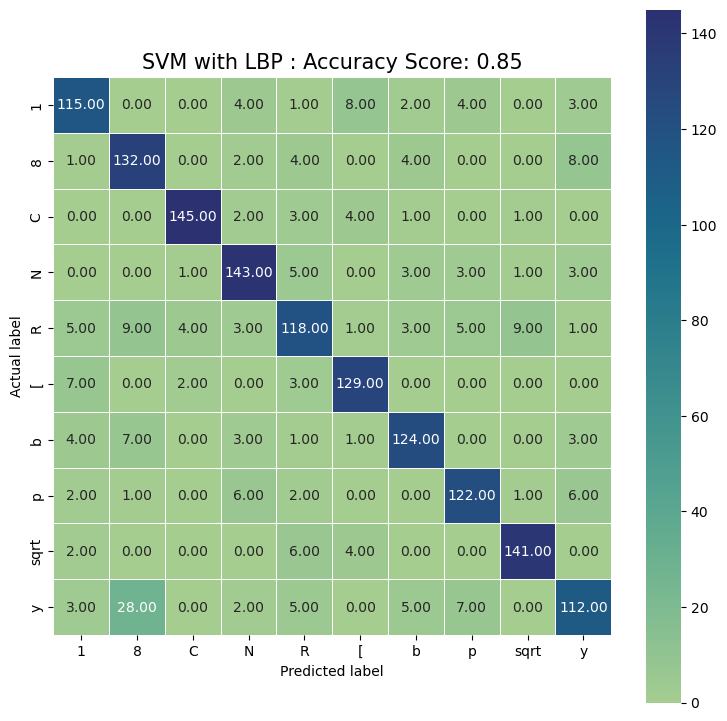

In [12]:
# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
class_names = ['1', '8', 'C', 'N', 'R', '[', 'b', 'p', 'sqrt', 'y']
sns.heatmap(lbp_cm, 
            annot=True,
            linewidths=0.5,
            fmt=".2f",
            square = True,
            cmap = 'crest',
            xticklabels = class_names,
            yticklabels = class_names
           );
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'SVM with LBP : Accuracy Score: {:.2f}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [13]:
report = metrics.classification_report(lbp_y_test, lbp_y_pred)
print("Classification Report for SVM with LBP:")
print(report)

Classification Report for SVM with LBP:
              precision    recall  f1-score   support

           1       0.83      0.84      0.83       137
           8       0.75      0.87      0.80       151
           C       0.95      0.93      0.94       156
           N       0.87      0.90      0.88       159
           R       0.80      0.75      0.77       158
           [       0.88      0.91      0.90       141
           b       0.87      0.87      0.87       143
           p       0.87      0.87      0.87       140
        sqrt       0.92      0.92      0.92       153
           y       0.82      0.69      0.75       162

    accuracy                           0.85      1500
   macro avg       0.86      0.86      0.85      1500
weighted avg       0.86      0.85      0.85      1500

